# Yelp Review Helpfulness Prediction & Ranking

This notebook looks at a product-facing question: which Yelp reviews are likely to be genuinely helpful, and can a model do enough to rank better reviews closer to the top? That makes the project as much about prioritization and product usefulness as it is about classification.

## Notebook Flow
- prepare and merge review, user, and business data
- engineer text and behavioral features
- compare classification models
- evaluate ranking quality and practical usefulness

## Problem Statement

The goal of this project is to predict review helpfulness and use predicted probabilities to rank reviews more effectively.

Main questions:
- Can review text and behavioral features predict whether a review receives at least one useful vote?
- Which reviewer and business signals are associated with helpful reviews?
- Can model scores improve review ranking in a product setting?

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Data

In [2]:
SAMPLE_SIZE = 100_000

def load_json_sample(path, sample_size=100000):
    rows = []
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            if i >= sample_size:
                break
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

reviews = load_json_sample("yelp_academic_dataset_review.json", SAMPLE_SIZE)
users = load_json_sample("yelp_academic_dataset_user.json", SAMPLE_SIZE)
business = pd.read_json("yelp_academic_dataset_business.json", lines=True)

print(reviews.shape)
print(users.shape)
print(business.shape)
reviews.head()

(100000, 9)
(100000, 22)
(150346, 14)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


## Data Preparation

In [3]:
reviews["date"] = pd.to_datetime(reviews["date"])

reviews["helpful_label"] = (reviews["useful"] >= 1).astype(int)

user_cols = ["user_id", "review_count", "useful", "funny", "cool", "fans"]
business_cols = ["business_id", "name", "categories", "stars", "review_count", "city", "state", "is_open"]

users_small = users[user_cols].rename(columns={
    "review_count": "user_review_count_raw",
    "useful": "user_useful_raw",
    "funny": "user_funny_raw",
    "cool": "user_cool_raw",
    "fans": "user_fans_raw",
})

business_small = business[business_cols].rename(columns={
    "stars": "business_stars_raw",
    "review_count": "business_review_count_raw",
})

df = reviews.merge(users_small, on="user_id", how="left")
df = df.merge(business_small, on="business_id", how="left")

df = df.dropna(subset=["text", "stars", "business_stars_raw"])
df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,helpful_label,user_review_count_raw,user_useful_raw,user_funny_raw,user_cool_raw,user_fans_raw,name,categories,business_stars_raw,business_review_count_raw,city,state,is_open
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,0,NaN,NaN,NaN,NaN,NaN,Turning Point of North Wales,"Restaurants, Breakfast & Brunch, Food, Juice B...",3.0,169,North Wales,PA,1
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,1,10.0,6.0,1.0,2.0,0.0,Body Cycle Spinning Studio,"Active Life, Cycling Classes, Trainers, Gyms, ...",5.0,144,Philadelphia,PA,0
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,0,1332.0,1660.0,675.0,1300.0,58.0,Kettle Restaurant,"Restaurants, Breakfast & Brunch",3.5,47,Tucson,AZ,1
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,1,NaN,NaN,NaN,NaN,NaN,Zaika,"Halal, Pakistani, Restaurants, Indian",4.0,181,Philadelphia,PA,1
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,1,NaN,NaN,NaN,NaN,NaN,Melt,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",4.0,32,New Orleans,LA,0


## Feature Engineering

In [4]:
def safe_upper_ratio(text):
    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(ch.isupper() for ch in letters) / len(letters)

df["review_char_len"] = df["text"].str.len()
df["review_word_count"] = df["text"].str.split().str.len()
df["exclamation_count"] = df["text"].str.count("!")
df["question_count"] = df["text"].str.count(r"\?")
df["uppercase_ratio"] = df["text"].apply(safe_upper_ratio)
df["avg_word_len"] = df["text"].apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df["review_year"] = df["date"].dt.year
df["review_month"] = df["date"].dt.month
df["review_weekday"] = df["date"].dt.weekday

df["user_review_count"] = df["user_review_count_raw"]
df["user_useful_votes"] = df["user_useful_raw"]
df["user_fans"] = df["user_fans_raw"]
df["business_review_count"] = df["business_review_count_raw"]
df["business_avg_stars"] = df["business_stars_raw"]

df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,helpful_label,user_review_count_raw,user_useful_raw,user_funny_raw,user_cool_raw,user_fans_raw,name,categories,business_stars_raw,business_review_count_raw,city,state,is_open,review_char_len,review_word_count,exclamation_count,question_count,uppercase_ratio,avg_word_len,review_year,review_month,review_weekday,user_review_count,user_useful_votes,user_fans,business_review_count,business_avg_stars
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,0,NaN,NaN,NaN,NaN,NaN,Turning Point of North Wales,"Restaurants, Breakfast & Brunch, Food, Juice B...",3.0,169,North Wales,PA,1,513,101,1,0,0.025189,4.069307,2018,7,5,NaN,NaN,NaN,169,3.0
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,1,10.0,6.0,1.0,2.0,0.0,Body Cycle Spinning Studio,"Active Life, Cycling Classes, Trainers, Gyms, ...",5.0,144,Philadelphia,PA,0,829,151,1,0,0.019908,4.483444,2012,1,1,10.0,6.0,0.0,144,5.0
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,0,1332.0,1660.0,675.0,1300.0,58.0,Kettle Restaurant,"Restaurants, Breakfast & Brunch",3.5,47,Tucson,AZ,1,339,55,0,0,0.044444,5.181818,2014,2,2,1332.0,1660.0,58.0,47,3.5
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,1,NaN,NaN,NaN,NaN,NaN,Zaika,"Halal, Pakistani, Restaurants, Indian",4.0,181,Philadelphia,PA,1,243,40,6,0,0.033898,4.900000,2015,1,6,NaN,NaN,NaN,181,4.0
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,1,NaN,NaN,NaN,NaN,NaN,Melt,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",4.0,32,New Orleans,LA,0,534,94,1,1,0.026128,4.691489,2017,1,5,NaN,NaN,NaN,32,4.0


## Exploratory Data Analysis

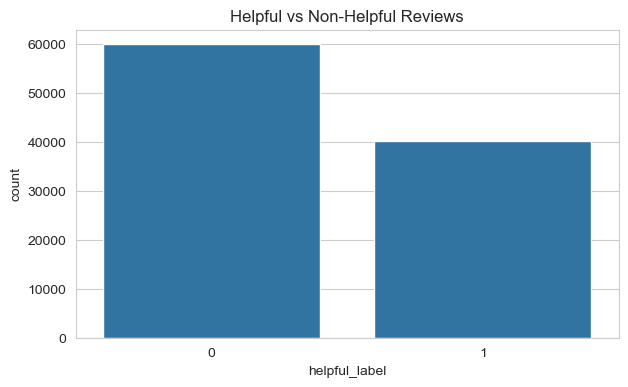

In [5]:
plt.figure(figsize=(7, 4))
sns.countplot(x="helpful_label", data=df)
plt.title("Helpful vs Non-Helpful Reviews")
plt.show()

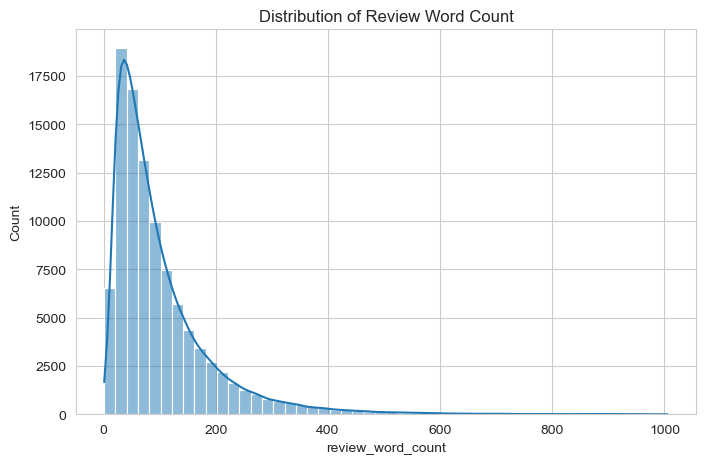

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["review_word_count"], bins=50, kde=True)
plt.title("Distribution of Review Word Count")
plt.show()

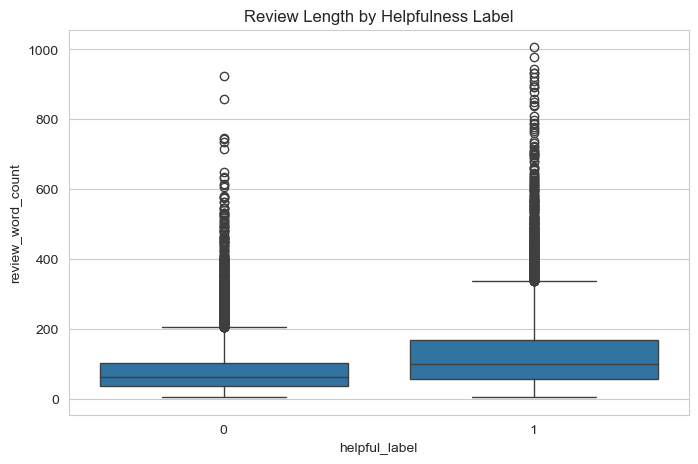

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.sample(min(20000, len(df)), random_state=42), x="helpful_label", y="review_word_count")
plt.title("Review Length by Helpfulness Label")
plt.show()

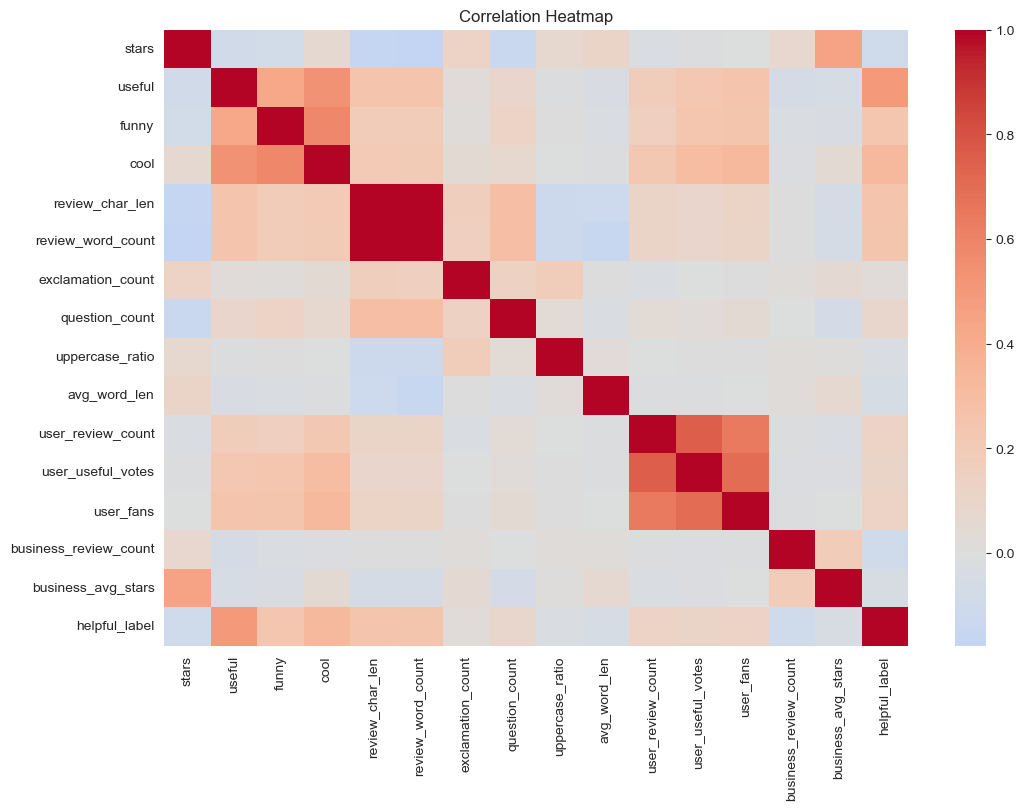

In [8]:
numeric_cols = [
    "stars", "useful", "funny", "cool", "review_char_len", "review_word_count",
    "exclamation_count", "question_count", "uppercase_ratio", "avg_word_len",
    "user_review_count", "user_useful_votes", "user_fans",
    "business_review_count", "business_avg_stars", "helpful_label"
]

plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## NLP Review Analysis


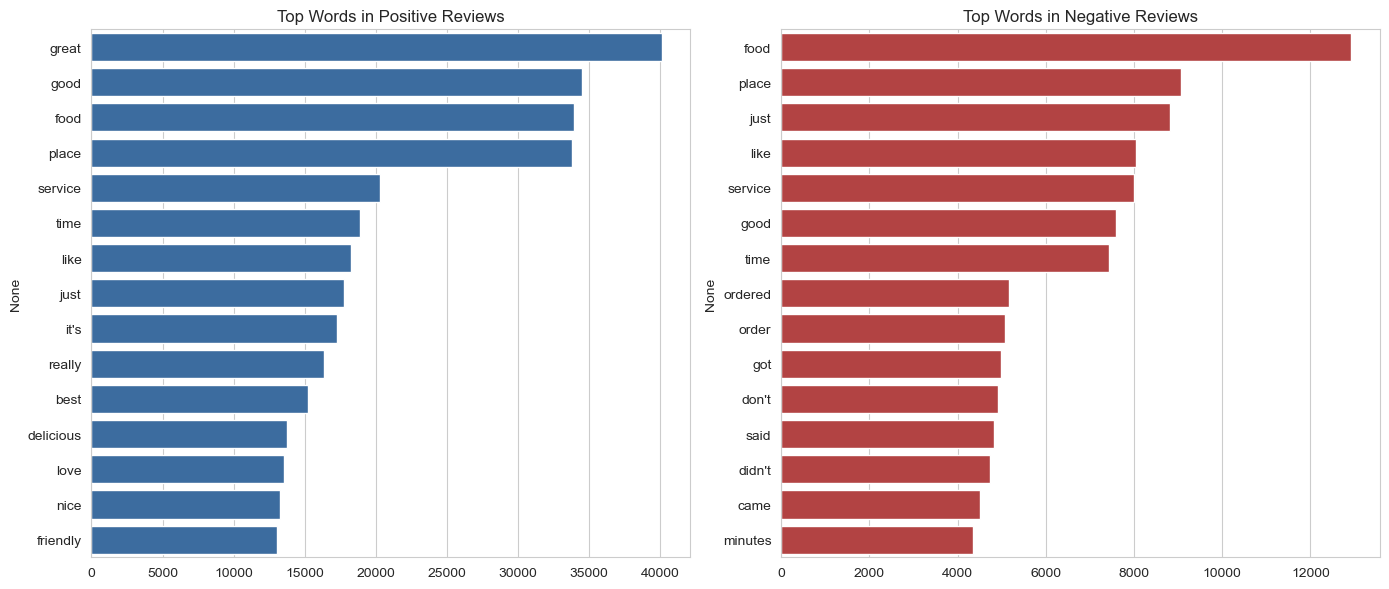

In [9]:
stop_words = set(ENGLISH_STOP_WORDS)

def get_top_words(text_series, top_n=15):
    text = " ".join(text_series.dropna().astype(str).str.lower())
    words = re.findall(r"[a-z']+", text)
    words = [word for word in words if len(word) > 2 and word not in stop_words]
    return pd.Series(words).value_counts().head(top_n)

positive_words = get_top_words(df.loc[df["stars"] >= 4, "text"])
negative_words = get_top_words(df.loc[df["stars"] <= 2, "text"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=positive_words.values, y=positive_words.index, ax=axes[0], color="#2b6cb0")
axes[0].set_title("Top Words in Positive Reviews")
sns.barplot(x=negative_words.values, y=negative_words.index, ax=axes[1], color="#c53030")
axes[1].set_title("Top Words in Negative Reviews")
plt.tight_layout()
plt.show()


In [10]:
restaurant_reviews = df[df["categories"].fillna("").str.contains("Restaurants", case=False, na=False)].copy()

top_business = (
    restaurant_reviews.groupby(["business_id", "name"], dropna=False)["review_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="review_volume")
    .head(10)
)

top_business


,business_id,name,review_volume
0,GBTPC53ZrG1ZBY3DT8Mbcw,Luke,950
1,W4ZEKkva9HpAdZG88juwyQ,Mr. B's Bistro,433
2,vN6v8m4DO45Z4pp8yxxF_w,Surrey's Café & Juice Bar,404
3,pSmOH4a3HNNpYM82J5ycLA,The Pancake Pantry,384
4,8uF-bhJFgT4Tn6DTb27viA,District Donuts Sliders Brew,365
5,SZU9c8V2GuREDN5KgyHFJw,Santa Barbara Shellfish Company,351
6,Zi-F-YvyVOK0k5QD7lrLOg,Muriel's Jackson Square,342
7,UCMSWPqzXjd7QHq7v8PJjQ,Prep & Pastry,341
8,M0r9lUn2gLFYgIwIfG8-bQ,Baileys' Range,327
9,EtKSTHV5Qx_Q7Aur9o4kQQ,Village Whiskey,316


In [11]:
selected_business_id = top_business.iloc[0]["business_id"]
selected_business_name = top_business.iloc[0]["name"]

example_reviews = df[df["business_id"] == selected_business_id][["name", "stars", "useful", "text"]].copy()

print("Selected Restaurant:", selected_business_name)
print("\nTop Positive Reviews")
display(example_reviews.sort_values(["stars", "useful"], ascending=[False, False]).head(3))

print("\nTop Negative Reviews")
display(example_reviews.sort_values(["stars", "useful"], ascending=[True, False]).head(3))


Selected Restaurant: Luke

Top Positive Reviews


,name,stars,useful,text
37555,Luke,5.0,48,Upscale bar/restaurant with an adjoining elega...
14825,Luke,5.0,12,Lüke. One of the first restaurants in NOLA I c...
61601,Luke,5.0,12,Come during 3 PM to 6 PM!!!! Really. Come duri...



Top Negative Reviews


,name,stars,useful,text
52369,Luke,1.0,3,Eek! Methinks not could not be more accurate! ...
10923,Luke,1.0,2,We never got the oysters that we ordered befor...
21334,Luke,1.0,2,If you like practicing your lip reading skills...


## Modeling

In [12]:
features = [
    "stars", "funny", "cool",
    "review_char_len", "review_word_count", "exclamation_count", "question_count",
    "uppercase_ratio", "avg_word_len",
    "review_year", "review_month", "review_weekday",
    "user_review_count", "user_useful_votes", "user_fans",
    "business_review_count", "business_avg_stars", "is_open"
]

target = "helpful_label"

model_df = df[features + [target, "business_id", "review_id", "useful"]].dropna().copy()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(46684, 18) (11672, 18)


In [13]:
log_model = LogisticRegression(max_iter=500, solver="liblinear")
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Logistic Regression Precision:", precision_score(y_test, log_pred))
print("Logistic Regression Recall:", recall_score(y_test, log_pred))
print("Logistic Regression F1:", f1_score(y_test, log_pred))
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, log_proba))

Logistic Regression Accuracy: 0.7344928032899246
Logistic Regression Precision: 0.8037288989669942
Logistic Regression Recall: 0.5789473684210527
Logistic Regression F1: 0.6730667791961177
Logistic Regression ROC AUC: 0.7965787029101141


In [14]:
rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Precision:", precision_score(y_test, rf_pred))
print("Random Forest Recall:", recall_score(y_test, rf_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))
print("Random Forest ROC AUC:", roc_auc_score(y_test, rf_proba))

Random Forest Accuracy: 0.7457162440027416
Random Forest Precision: 0.7867779783393501
Random Forest Recall: 0.6328493647912886
Random Forest F1: 0.7014685174009254
Random Forest ROC AUC: 0.8203083296664587


In [15]:
gb_model = GradientBoostingClassifier(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print("Gradient Boosting Precision:", precision_score(y_test, gb_pred))
print("Gradient Boosting Recall:", recall_score(y_test, gb_pred))
print("Gradient Boosting F1:", f1_score(y_test, gb_pred))
print("Gradient Boosting ROC AUC:", roc_auc_score(y_test, gb_proba))

Gradient Boosting Accuracy: 0.7489718985606579
Gradient Boosting Precision: 0.7937158469945356
Gradient Boosting Recall: 0.6326678765880218
Gradient Boosting F1: 0.7041001817814583
Gradient Boosting ROC AUC: 0.8229599954289243


## Ranking Evaluation

In [16]:
test_index = X_test.index
ranking_df = model_df.loc[test_index, ["business_id", "review_id", "useful", "helpful_label"]].copy()
ranking_df["score"] = gb_proba

def precision_at_k(group, k=5):
    topk = group.sort_values("score", ascending=False).head(k)
    if len(topk) == 0:
        return np.nan
    return topk["helpful_label"].mean()

business_ranking = ranking_df.groupby("business_id").apply(precision_at_k, k=5).dropna()
print("Mean Precision@5:", business_ranking.mean())

Mean Precision@5: 0.5322879115597212


In [17]:
top_reviews = ranking_df.sort_values("score", ascending=False).head(10)
top_reviews

,business_id,review_id,useful,helpful_label,score
40672,hn3Rg2JrhQoDJBEhrpuwWg,DpZCSeWZr5I9gCd7ZSZeQg,33,1,0.984586
34003,e9lqPiNqcCfu97uCZerq0g,LK2StoDQLfe5VTmfT-7K0g,7,1,0.977556
19307,vN6v8m4DO45Z4pp8yxxF_w,bP1jNq223JW6Y1Rduv3osg,18,1,0.972880
40470,jlkDIOPoRP9SJXTkRVpkMQ,8pYP0XKByFXO0Dn4GfEbnQ,13,1,0.972381
67603,OHzX-ZD9qyoeoxR8Z0dlIA,bM_I5l-xbzz2FHHXnaxRMw,8,1,0.972069
6617,35xe-xLwaYiA6ZfFvQC29w,9BckYdlcsXPrR0C86UkiTw,14,1,0.972059
93008,7mpYTDb24SywNMRn3yeakQ,kBGxhsvzsGEW1cckYJeCOg,26,1,0.972033
99688,85HTEU6hNsdK4gv1A4Cfww,9Emoc6UKRdUmVTTuMm7wzg,7,1,0.971814
20514,aiggx_mzALX3kZOGYTPdjg,tkweJH1iRDSUG5stKf7krQ,11,1,0.971772
52316,GJC3QI31IV5Q4kVHIM498Q,os98NxRaLT_4SKPbEtjzAQ,33,1,0.971690


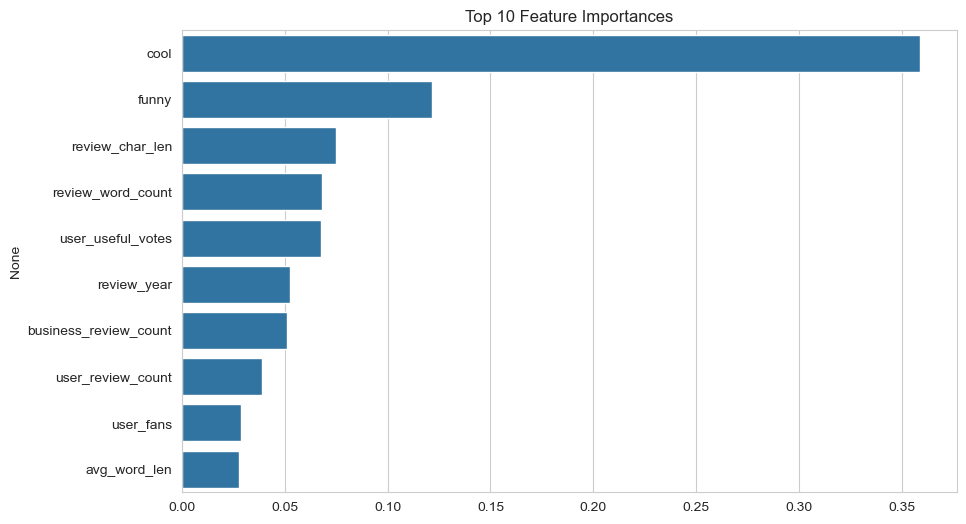

In [18]:
feature_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values[:10], y=feature_importance.index[:10])
plt.title("Top 10 Feature Importances")
plt.show()

## Conclusion

The most useful result here is not just that review helpfulness can be predicted. It is that the predicted scores are good enough to support a ranking view of the problem, which is much closer to how a real review platform would actually use the output.

The tree-based models work best because helpfulness depends on a mix of writing behavior, reviewer history, and business context. That combination makes the project feel like a good bridge between NLP-style feature work and product analytics.